# Audio Steganography - Project Plan

Szymon Jędrzejczak, Bartosz Pyzio, Szymon Wieczorek

---

## Literature Review

### [1] Baseline - Comparative Benchmarking of Classical Techniques
**Comparative Analysis of Audio Steganography Methods**
DergiPark / University of Twente BA thesis (essay.utwente.nl/95988)

The foundational quantitative reference for the project. Benchmarks LSB, Spread Spectrum, Cepstrum/Echo Hiding, and Wavelet Coding on a standardised dataset across SNR, capacity, and robustness. The key finding is a strict inverse correlation between payload size and signal quality across all methods, and a clear robustness ranking: DSSS > Echo Hiding > Wavelet > LSB. The SNR figures from this source (LSB ~97 dB, DSSS ~44 dB, Echo Hiding ~28 dB) are used directly in the project's comparison section. Also surfaces the counterintuitive "legacy vs. neural" paradox: classical spread spectrum outperforms most GAN-based approaches under additive noise.

### [2] Phase Coding - Improved Mid-Frequency Adaptive Algorithm
**An Improved Phase Coding Audio Steganography Algorithm**
arXiv 2408.13277 (2024)

Extends the classical Fourier phase coding method by dynamically segmenting the signal and targeting the mid-frequency range (roughly 1-8 kHz) for embedding, rather than encoding everything into the first block's absolute phase. The motivation is psychoacoustic: low frequencies carry the bulk of perceptible energy and should not be disturbed; high frequencies are aggressively discarded by lossy compression. By concentrating the payload in mid-frequency phase components, the algorithm achieves better BER under compression and lower steganalysis detectability than the classical single-block approach. Directly informs Section 2 of the notebook.

### [3] Spectrogram Steganography - Chaotic STFT/DWT Image Concealment
**A robust audio steganography technique based on image encryption using different chaotic maps**
PMC / NCBI (PMC11436861, 2024)

Describes a system for hiding a full image inside an audio file by injecting chaotic-map-encrypted pixel data into the high-frequency STFT coefficients of the carrier. The chaotic map pre-scrambles the image's pixel distribution before embedding, so that even if an adversary locates the modified coefficients, the data is visually meaningless without the decryption key. Reports PSNR exceeding 91.2 dB - essentially inaudible. This is the rigorous version of the simpler spectrogram painting approach and is the main reference for Section 3.

### [4] Echo Hiding - Cepstrum Extraction and Improved Kernels
**Presenting a Method for Improving Echo Hiding**
ResearchGate (349335429)

Addresses the two main weaknesses of classical echo hiding: bipolar echo kernels that produce audible artifacts, and susceptibility to cepstral steganalysis. Proposes hybrid kernels and chaotic pseudo-random key generation to vary the echo delay parameters across segments, defeating fixed-threshold cepstral detectors. The paper also provides the cepstrum-based extraction algorithm - inverse FFT of the log power spectrum, then autocorrelation peak detection - that the notebook implements for decoding. Establishes the critical perceptual threshold: delays of 1-3 ms are perceived as natural reverberation; beyond 3 ms the echo becomes audible as a distinct artifact.

### [5] Spread Spectrum - DSSS and Gaussian Cyclostationarity Camouflage
**Gaussian-Distributed Spread-Spectrum for Covert Communications**
PMC / NIH (PMC10144851, 2024)

Covers both the standard DSSS embedding mechanism (bipolar modulation with a pseudo-random chip sequence) and the more advanced GDSS extension. The key vulnerability of standard DSSS is cyclostationarity - the periodic chip sequence leaves a detectable pattern in cyclic spectral analysis even if the message cannot be read. GDSS addresses this by mathematically reshaping the transmitted signal to follow a Gaussian amplitude distribution, making it statistically indistinguishable from thermal noise. Directly motivates the steganalysis experiment in Section 5: the cyclic spectral detector catches standard DSSS but would be defeated by GDSS.

### [6] MP3 Bitstream - Huffman Table Transformation
**High capacity reversible data hiding in MP3 based on Huffman table transformation**
AIMS Press / Mathematical Biosciences and Engineering (DOI: 10.3934/mbe.2019158)

The technical reference for the most elegant technique in the project. The MP3 standard defines multiple Huffman tables for entropy coding quantised MDCT coefficients; the steganographic algorithm exploits the fact that paired tables produce acoustically equivalent results, using the table selection itself as the information channel. Zero acoustic distortion (no sample values are changed), fully reversible, and the payload is extracted by reading frame header metadata rather than decoding the audio. A Python library (`mp3-steganography-lib`) implements this directly, making it the only technique in the project that operates natively on a compressed MP3 without a decode/re-encode cycle.

### [7] Deep Learning Ceiling - FGS-Audio Adversarial Framework
**FGS-Audio: Fixed-Decoder Framework for Audio Steganography with Adversarial Perturbation Generation**
ResearchGate (2025)

Included as a "ceiling" reference rather than an implementation target. FGS-Audio integrates a psychoacoustic masking model directly into gradient descent - the network computes per-frequency inaudibility thresholds and constrains adversarial perturbations to remain beneath them. Training includes simulated distortion layers (MP3 compression, filtering, noise) so the decoder learns invariant features. Not feasible to implement from scratch, but its architecture motivates the extensions section and defines the theoretical ideal against which classical methods are honestly compared.

---

## Overview

The project is structured as a single Jupyter notebook implementing five steganographic techniques of progressively increasing sophistication, followed by a steganalysis section that attempts to detect each one, and a final comparison. The goal is to understand the embedding and extraction mechanics hands-on rather than treating techniques as black boxes.

The core structure per technique is:

```
Cover audio + Secret payload
        \/
  Embedding algorithm
        \/
  Stego audio file
        \/
  Extraction algorithm -> Recovered payload
        \/
  Quality metrics (SNR, BER, capacity)
        \/
  Steganalysis attempt - can we detect it?
```

---

## Environment & Dependencies

| Library | Purpose |
|---|---|
| `numpy`, `scipy` | FFT, IFFT, signal processing, correlation |
| `librosa` | Audio loading, STFT, spectrogram display |
| `soundfile` | PCM read/write for WAV I/O |
| `pydub` | Audio manipulation and format conversion |
| `matplotlib` | Waveform, spectrogram, and metric plots |
| `Pillow` | Image loading/saving for image-in-audio techniques |
| `wave` | Raw WAV frame access for LSB |
| `mp3-steganography-lib` | Huffman table swapping for MP3 |
| `ffmpeg` (subprocess) | Compression attack simulation |

---

## Part 1 - Baseline: LSB Steganography

**Difficulty:** Low. **Value:** High - establishes the vocabulary and metrics for everything that follows.

LSB is the entry point. It is not the most interesting technique, but implementing it cleanly sets up the whole notebook: it introduces the encode/decode loop, the SNR measurement, the BER calculation, and the capacity formula that every subsequent section reuses.

### 1.1 Implementation

Using the `wave` module for direct byte access:
- Read all audio frames into a mutable byte array
- Encode text or binary payload by replacing the LSB of each sample byte (bitwise AND to zero it, OR to inject the payload bit)
- Prepend a fixed-length header encoding payload length so the decoder knows when to stop
- Decode by extracting LSBs sequentially and reconstructing the byte stream

Extend to 2-bit and 3-bit variants: overwrite the two or three least significant bits per sample. Plot SNR vs. bits-used-per-sample to make the capacity/quality tradeoff concrete.

### 1.2 Steganalysis: LSB Distribution Test

The LSB distribution of natural audio is not perfectly random - the least significant bit of audio samples correlates weakly with the sample above it. Embedding a uniformly random payload disrupts this correlation and drives the LSB histogram toward 50/50. Implement a chi-squared test on the LSB histogram before and after embedding. This is the core of StegoScan-style heuristic detection - fast to implement and produces a clear pass/fail result.

### 1.3 Robustness Test

Apply an MP3 compression round-trip (WAV -> MP3 -> WAV via FFmpeg, then re-extract). The payload will be destroyed. This is not a flaw to fix - it is an honest demonstration of why more sophisticated techniques exist, and it motivates everything in Parts 2-5.

---

## Part 2 - Phase Coding

**Difficulty:** Medium. **Value:** High - introduces frequency-domain thinking and the psychoacoustic principle of phase deafness.

### 2.1 Classical Phase Coding

Implement the standard algorithm in numpy:
1. Segment the audio into N non-overlapping blocks of length L
2. Apply FFT to each block; extract magnitude and phase matrices
3. Compute inter-block phase differences: Δφᵢ = φᵢ - φᵢ₋₁
4. Map payload bits to phase values: `0 -> π/2`, `1 -> -π/2`
5. Inject the encoded phase into block 0 only; enforce DFT symmetry for real-valued output
6. Propagate original Δφ differences forward through all subsequent blocks to maintain phase continuity
7. Reconstruct via IFFT

Extraction: the receiver takes block 0, runs FFT, and checks whether the phase at each target bin is closer to π/2 or -π/2.

The key limitation to demonstrate explicitly: because the payload is entirely in block 0, capacity is capped at L/2 bits (half the block size, due to conjugate symmetry). Increasing L for more capacity begins to warp inter-block phase relations and introduces audible artifacts.

### 2.2 Improved Mid-Frequency Variant (arXiv 2408.13277)

Extend the classical approach following the 2024 paper: instead of embedding only in block 0, embed one chunk of payload per block, but restrict the modified frequency bins to the mid-frequency range (e.g., 1-8 kHz). Below that range, phase changes are perceptible because those frequencies dominate the perceived signal. Above it, phase shifts survive compression poorly. Plot which frequency bins are modified to make the targeting concrete. Compare BER after an MP3 round-trip against the classical single-block approach - the mid-frequency version degrades more gracefully.

---

## Part 3 - Spectrogram Steganography (Image in Audio)

**Difficulty:** Medium. **Value:** High - visually the most striking result in the notebook, and conceptually unlike all other techniques here.

This section hides a grayscale image inside an audio file by synthesising the image's pixel values as frequency amplitudes over time. The resulting audio sounds like noise but renders the image when viewed as a spectrogram.

### 3.1 Basic Spectrogram Painting

- Load a grayscale image; scale it to target dimensions (width = time steps, height = frequency bins)
- For each column (time step), construct a frequency-domain vector where each bin's amplitude equals the corresponding pixel's brightness
- Apply inverse FFT per column to get a time-domain audio segment
- Concatenate all segments into the final synthesised audio

The audio sounds jarring in isolation. Play it and show the spectrogram - the image appears immediately. This is the most visually rewarding single result in the project.

### 3.2 Psychoacoustic Camouflage

Spectrogram painting is only useful if the resulting signal can be hidden under real audio. Rather than a left/right split - which is immediately obvious to any listener wearing headphones, since one channel would sound like a fax machine - use a mid-side (M/S) representation:

- Mid = (L + R) / 2 - the mono-compatible sum, carrying all dominant musical energy
- Side = (L - R) / 2 - the stereo difference signal, carrying only spatial width information

The side channel already contains legitimate low-level content in any real stereo recording (instrument panning, room ambience), so injecting additional signal into it is far less suspicious. On mono playback - phone speakers, cheap Bluetooth - the side channel cancels out entirely ((M+S) + (M-S) = 2M), making the hidden content completely inaudible on those systems.
Implementation:
1. Decode the stereo carrier to L and R arrays
2. Compute M = (L + R) / 2 and S = (L - R) / 2
3. Generate the image-audio signal (from Section 3.1), frequency-shifted to 13-19 kHz and gain-reduced by 30-40 dB
4. Add the image signal to the S channel
5. Reconstruct L = M + S and R = M - S and write the output file

Show three spectrograms side by side: the original carrier, the stego output (which should look essentially identical), and the isolated S channel (which reveals the image). Also verify the mono cancellation property explicitly by summing L + R and showing the image disappears.

---

## Part 4 - Echo Hiding

**Difficulty:** Medium-High. **Value:** Good - introduces cepstrum analysis, which is both the decoding primitive and the main steganalysis attack, making for an elegant self-contained section.

### 4.1 Echo Kernel Implementation

Segment the audio into blocks (typical block size: 1000-4000 samples). For each block:
- Convolve with an echo kernel parameterised by delay d and decay α: `h(t) = δ(t) + α·δ(t - d)`
- Use delay d₀ (e.g. 1.0 ms) to encode binary `0`, delay d₁ (e.g. 1.5 ms) to encode binary `1`
- Apply a smoothing mixer at block boundaries to avoid audible clicks (linear cross-fade between adjacent kernel responses)

Keep α ≤ 0.5 and delays strictly within the 1-3 ms perceptual window established by source [4]. Show the waveform before and after - the difference should be essentially invisible.

### 4.2 Cepstrum Extraction

To decode:
1. Compute the power spectrum of each block: `|FFT(x)|²`
2. Take the log - this converts the multiplicative echo structure into an additive one
3. Apply inverse FFT to yield the cepstrum
4. Compute the autocorrelation of the cepstrum; identify the dominant peak at short quefrency
5. Compare the peak location to d₀ vs. d₁ thresholds and output the corresponding bit

This is the most DSP-intensive extraction step in the notebook. Plot the cepstrum for a block encoded with each delay value - the peak shifts visibly and measurably between d₀ and d₁.

### 4.3 Steganalysis: Cepstral Peak Detector

The same cepstrum analysis used for extraction is also the standard steganalysis attack. On a clean audio file, the cepstrum has no strong periodic peak at short quefrency. On an echo-encoded file, a clear peak appears at the echo delay. Implement a simple detector: flag any block where the cepstrum autocorrelation exceeds a threshold at sub-5 ms quefrency. Quantify the false positive rate on clean audio vs. detection rate on stego audio. Note explicitly that the improved hybrid kernels from source [4] were designed to defeat exactly this detector.

---

## Part 5 - Spread Spectrum (DSSS)

**Difficulty:** Medium-High. **Value:** High - the most robust classical technique, and the steganalysis experiment (cyclostationarity detection) is genuinely interesting and replicates current research.

### 5.1 DSSS Embedding

Following the standard mechanism:
- Map payload bits to bipolar values: `0 -> -1`, `1 -> +1`
- Generate a pseudo-random chip sequence using a seeded PRNG (the seed is the shared key); chip rate >> message bit rate (e.g., 100:1 ratio)
- Multiply the bipolar message by the chip sequence to produce the spread signal
- Scale to a target amplitude ε (typically 0.001-0.01 relative to peak audio amplitude)
- Add to the cover audio: `stego = cover + ε · (message ⊗ chip)`

The spread signal is buried below the noise floor and is perceptually invisible at low ε.

### 5.2 Correlation Extraction

Recovery does not require knowing the original audio:
- Multiply the stego audio by the same chip sequence (the receiver must know the PRNG seed)
- Integrate over chip-length windows - the chip is orthogonal to the cover audio, so the cover contribution averages toward zero, while the payload contribution coherently accumulates
- Threshold the correlation output: positive -> `1`, negative -> `0`

Demonstrate graceful degradation: increase ε, add noise, apply MP3 compression. BER rises slowly rather than jumping catastrophically, unlike LSB. This directly illustrates why DSSS is the most robust entry in the comparison table.

### 5.3 Steganalysis: Cyclic Spectral Analysis

Standard DSSS has a detectable footprint: the repeating chip sequence creates cyclostationary periodicity in the signal's second-order statistics, visible as a peak in the cyclic spectral density at the chip repetition frequency. Implement a simplified cyclic autocorrelation estimator:
- Compute the cyclic autocorrelation of the stego signal at the chip repetition period
- A clean audio file shows no significant peak; a DSSS-stego file shows a clear one

This directly replicates the attack that the GDSS paper (source [5]) was designed to defeat. Note that GDSS would render this detector ineffective by reshaping the amplitude distribution - a natural extension for Section 8.

---

## Part 6 - MP3 Huffman Table Swapping

**Difficulty:** Low (the library handles the heavy lifting). **Value:** High - conceptually the most elegant technique, and the only one that operates on a compressed MP3 without touching audio samples at all.

### 6.1 Implementation via mp3-steganography-lib

The `mp3-steganography-lib` library exposes a facade over the Huffman swapping logic:
- Instantiate the encoder with a WAV source and a target bitrate
- Call `encode_wav_to_mp3(message)` - the library converts to MP3 while embedding by selecting Huffman table variants according to payload bits at each frame
- Call `decode_mp3(stego_file)` on the receiver side to extract the message by reading frame header metadata, without decoding the audio at all

### 6.2 What Makes This Structurally Different

Demonstrate two properties that no other technique here can claim:

**Zero acoustic distortion:** Compare the spectrogram of the Huffman-stego MP3 to a straight encode of the same WAV. They are identical - the audio samples are unchanged, only the compression metadata differs. SNR is theoretically infinite.

**Reversibility:** Extract the payload, restore the optimal Huffman tables, compare the result to a clean encode - they match. The steganographic footprint can be completely removed, leaving no forensic trace in the bitstream.

Contrast this with the LSB MP3 round-trip from Part 1: LSB embeds into WAV samples and is destroyed by the same compression that Huffman swapping uses as its carrier.

---

## Part 7 - Comparison and Summary

### 7.1 Metrics Table

Run all five techniques on the same carrier file with the same payload and populate a comparison table, using the SNR benchmarks from source [1] as reference points:

| Technique | Avg SNR (dB) | Capacity | BER after MP3 roundtrip | Detectable? |
|---|---|---|---|---|
| LSB (1-bit) | ~97 | Very high | 100% (destroyed) | Yes - chi^2 test |
| Phase Coding | High | Low | Moderate | Hard |
| Spectrogram (STFT/DWT) | ~91 | Medium | Low | Low (visual only) |
| Echo Hiding | ~28 | Low-Medium | Moderate | Yes - cepstral peak |
| DSSS | ~44 | Moderate | Low | Partial - cyclostat. |
| Huffman Swapping | Infinite (0 distortion) | Medium | 0% (native to MP3) | Structural only |

### 7.2 Capacity/Quality Trade-off Plot

Plot SNR vs. payload size for LSB (varying bits-per-sample), phase coding (varying block size), and DSSS (varying ε and chip rate). This makes the steganographic triad - imperceptibility, capacity, robustness - concrete and visual rather than abstract.

### 7.3 Robustness Ladder

Test all techniques under the same attack sequence and record BER at each stage:
1. Clean extraction (no attack)
2. Additive white Gaussian noise at -40 dB
3. Low-pass filter at 8 kHz
4. MP3 re-encode at 128 kbps

DSSS should survive steps 1-3; Huffman swapping survives all four; LSB fails at step 2. This ladder tells the complete story of why the technique landscape is not a single-winner problem.

---

## Possible Extensions (If Time Allows)

**GDSS Implementation** - the Gaussian-distributed countermeasure to the cyclostationary detector from source [5]. Requires reshaping the spread signal's amplitude distribution before addition to the carrier; mathematically tractable and would directly demonstrate that the steganalysis from Section 5.3 can be defeated.

**AAC_SIGN** - the AAC equivalent of Huffman swapping: flip the sign bits of low-amplitude QMDCT coefficients. Requires parsing AAC bitstream headers, which is more involved than MP3 due to AAC's more complex frame structure. No ready library equivalent to mp3-steganography-lib exists.

**Image payload via DSSS** - extend the spread spectrum section to hide a full greyscale image by treating the flattened pixel array as a bitstream, then reconstructing and displaying the recovered image. The correlation-based extraction already generalises; it only requires a quantisation and reshape step at the output.

**Adaptive phase coding** - implement the per-band frequency sensitivity sweep (inject perturbations per frequency bin, measure phase detectability) to empirically identify which bins are least perceptible to both the HAS and steganalysis, and target those preferentially.

---

## Recommended Notebook Structure

```
Section 0 - Setup & imports
            Helper functions: snr(), ber(), capacity_bits(), plot_spectrogram()
Section 1 - LSB
  1.1  Encode and decode text payload in WAV
  1.2  SNR vs bits-per-sample sweep
  1.3  LSB distribution steganalysis (chi^2 test)
  1.4  MP3 round-trip robustness test -> BER = 100%
Section 2 - Phase Coding
  2.1  Classical FFT phase coding (block 0 only)
  2.2  Mid-frequency adaptive variant (arXiv 2408.13277)
  2.3  BER comparison under compression
Section 3 - Spectrogram Steganography
  3.1  Basic image-to-spectrogram synthesis
  3.2  Stereo channel psychoacoustic camouflage
  3.3  Chaotic STFT/DWT embedding and extraction (PMC11436861)
  3.4  PSNR measurement vs. paper benchmark
Section 4 - Echo Hiding
  4.1  Echo kernel construction and block embedding
  4.2  Cepstrum-based extraction
  4.3  Steganalysis: cepstral peak detector + false positive rate
Section 5 - Spread Spectrum (DSSS)
  5.1  Bipolar encoding and chip spreading
  5.2  Correlation-based extraction
  5.3  BER under noise and compression (graceful degradation)
  5.4  Steganalysis: cyclic spectral density estimator
Section 6 - MP3 Huffman Table Swapping
  6.1  Encode and decode via mp3-steganography-lib
  6.2  Zero-distortion verification (spectrogram comparison)
  6.3  Reversibility demonstration
Section 7 - Comparison
  7.1  Metrics table
  7.2  Capacity/quality trade-off plots
  7.3  Robustness ladder across all techniques
Section 8 - Extensions (placeholder cells)
```

## Section 0 - Setup & Imports


In [1]:
%pip install numpy scipy librosa soundfile matplotlib Pillow pydub ffmpeg-python pandas ipython


   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ---------------------------------------- 3/3 [ffmpeg-python]

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# -- Setup environment in Colab --
import os

if not os.path.exists("assets"):
    print("Fetching assets from GitHub...")
    !git clone --quiet https://github.com/Monczak/audio-steganography.git /tmp/audio-steg
    !mv /tmp/audio-steg/assets .
    !rm -rf /tmp/audio-steg
    print("Assets mounted and ready!")


In [3]:
import io
import wave
import struct
import subprocess
import tempfile
import warnings
import numpy as np
import scipy.io.wavfile as wav
import librosa
import librosa.display
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
from IPython.display import Audio, display, HTML

warnings.filterwarnings("ignore")

SR = 44100
ASSETS_DIR = Path("assets")
OUTPUT = Path("output")
AUDIO_DIR = ASSETS_DIR / "audio"
IMG_DIR = ASSETS_DIR / "img"
OUTPUT_AUDIO_DIR = OUTPUT / "audio" 

In [4]:
# -- Helper Functions: Metrics --

def snr(original, modified):
    """Signal-to-Noise Ratio in dB."""
    original = np.asarray(original, dtype=np.float64)
    modified = np.asarray(modified, dtype=np.float64)
    noise = original - modified
    power_signal = np.sum(original ** 2)
    power_noise = np.sum(noise ** 2)
    if power_noise == 0:
        return float("inf")
    return 10 * np.log10(power_signal / power_noise)

def psnr(original, modified):
    """Peak Signal-to-Noise Ratio in dB."""
    original = np.asarray(original, dtype=np.float64)
    modified = np.asarray(modified, dtype=np.float64)
    noise = original - modified
    mse = np.mean(noise ** 2)
    if mse == 0:
        return float("inf")
    peak = np.max(np.abs(original))
    return 10 * np.log10(peak ** 2 / mse)

def ber(original_bytes, recovered_bytes):
    """Bit Error Rate: fraction of mismatched bits (now unpacks bytestrings)."""
    orig_arr = np.frombuffer(original_bytes, dtype=np.uint8)
    recov_arr = np.frombuffer(recovered_bytes, dtype=np.uint8)
    
    orig_bits = np.unpackbits(orig_arr) if len(orig_arr) > 0 else np.array([])
    recov_bits = np.unpackbits(recov_arr) if len(recov_arr) > 0 else np.array([])
    
    length = min(len(orig_bits), len(recov_bits))
    if length == 0:
        return 1.0
        
    errors = np.sum(orig_bits[:length] != recov_bits[:length])
    return errors / length

def capacity_bits(n_samples, bits_per_sample=1):
    """Maximum payload capacity in bits (excluding header)."""
    return n_samples * bits_per_sample

In [5]:
# -- Helper Functions: Data Conversion --

def load_audio(file_path):
    """Load an audio file and ensures it is converted to mono."""
    audio, sr = sf.read(file_path)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    return audio, sr

def text_to_bytes(text):
    """Convert a string directly to a bytestring."""
    return text.encode("utf-8")

def bytes_to_text(b):
    """Convert a bytestring back to a string."""
    return b.decode("utf-8", errors="replace")

In [6]:
# -- Helper Functions: Visualization & Audio --

def plot_spectrogram(audio, sr, title="Spectrogram", ax=None):
    """Display a mel spectrogram."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis="time", y_axis="mel", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")

def plot_waveform(audio, sr, title="Waveform", ax=None):
    """Display the time-domain waveform."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(12, 3))
    t = np.arange(len(audio)) / sr
    ax.plot(t, audio, linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(0, t[-1])

def mp3_roundtrip(input_wav, bitrate="128k"):
    """WAV -> MP3 -> WAV round-trip via ffmpeg. Returns path to recovered WAV."""
    mp3_path = input_wav.replace(".wav", "_compressed.mp3")
    recovered_path = input_wav.replace(".wav", "_recovered.wav")
    subprocess.run(["ffmpeg", "-y", "-i", input_wav, "-b:a", bitrate, mp3_path], capture_output=True)
    subprocess.run(["ffmpeg", "-y", "-i", mp3_path, recovered_path], capture_output=True)
    return recovered_path

In [7]:
# -- High-level Evaluation Helpers --

def display_audio_comparison(cover_audio, stego_audio, sr, title="Audio Comparison"):
    """Displays spectrograms and playable audio for cover vs stego."""
    print(f"\n{"="*20} {title} {"="*20}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_spectrogram(cover_audio, sr, title="Original Spectrogram", ax=axes[0])
    plot_spectrogram(stego_audio, sr, title="Stego Spectrogram", ax=axes[1])
    plt.tight_layout()
    plt.show()
    
    print("Original Audio:")
    display(Audio(data=cover_audio, rate=sr))
    print("Stego Audio:")
    display(Audio(data=stego_audio, rate=sr))

## Section 1 - LSB Steganography

The simplest steganographic technique: replace the least significant bit(s) of each audio sample with payload data. Conceptually trivial, but it establishes the encode/decode loop, metrics vocabulary, and steganalysis baseline that every subsequent section builds on.

**Key trade-off:** More bits per sample = higher capacity but lower SNR and easier detection.


### 1.1 - LSB Encode & Decode (1-bit, 2-bit, 3-bit variants)


In [ ]:
def lsb_encode(audio_data, payload_bytes, n_bits=1):
    original_shape = audio_data.shape
    # Flatten array to seamlessly process stereo/multi-channel samples
    samples = np.int16(np.asarray(audio_data).flatten() * 32767)
    
    # Header: 32 bits (4 bytes) representing the payload length in bytes
    header = len(payload_bytes).to_bytes(4, byteorder="big")
    full_payload = header + payload_bytes
    
    total_bits = len(full_payload) * 8
    samples_needed = (total_bits + n_bits - 1) // n_bits
    
    if samples_needed > len(samples):
        raise ValueError(f"Payload too large: need {samples_needed} samples, have {len(samples)}")
        
    mask = ~((1 << n_bits) - 1) & 0xFFFF
    bit_idx = 0
    stego_samples = samples.copy()
    
    for i in range(samples_needed):
        val = int(stego_samples[i]) & 0xFFFF
        val = val & mask
        
        chunk = 0
        for b in range(n_bits):
            if bit_idx < total_bits:
                byte_val = full_payload[bit_idx // 8]
                bit_val = (byte_val >> (7 - (bit_idx % 8))) & 1
                chunk = (chunk << 1) | bit_val
                bit_idx += 1
            else:
                chunk = chunk << 1
                
        val = val | chunk
        
        # Restore two's complement constraint for negative values
        if val >= 0x8000:
            val -= 0x10000
        stego_samples[i] = val
        
    # Reshape the flattened outcome back to it's original multi-channel setup
    return (stego_samples.astype(np.float64) / 32767.0).reshape(original_shape)


def lsb_decode(stego_audio, n_bits=1):
    # Flatten array to seamlessly process stereo/multi-channel samples
    samples = np.int16(np.asarray(stego_audio).flatten() * 32767)
    
    extracted_bytes = bytearray()
    current_byte = 0
    bits_in_current_byte = 0
    
    payload_len = 0
    header_parsed = False
    
    for i in range(len(samples)):
        val = int(samples[i]) & 0xFFFF
        
        for b in range(n_bits - 1, -1, -1):
            bit_val = (val >> b) & 1
            current_byte = (current_byte << 1) | bit_val
            bits_in_current_byte += 1
            
            if bits_in_current_byte == 8:
                extracted_bytes.append(current_byte)
                current_byte = 0
                bits_in_current_byte = 0
                
                # Setup payload length once the 4-byte header is assembled
                if not header_parsed and len(extracted_bytes) == 4:
                    payload_len = int.from_bytes(extracted_bytes, byteorder='big')
                    header_parsed = True
                    
                # Return successfully if we've received the entire expected payload
                if header_parsed and len(extracted_bytes) == 4 + payload_len:
                    return bytes(extracted_bytes[4:])
                    
    # Failsafe if payload ends up truncated by audio end
    return bytes(extracted_bytes[4:4 + payload_len]) if len(extracted_bytes) > 4 else b""

In [ ]:
def test_lsb_variant(cover_audio, sr, payload_bytes, n_bits):
    """Runs an LSB encode/decode test in-memory and returns metrics."""
    stego_audio = lsb_encode(cover_audio, payload_bytes, n_bits)
    recovered_bytes = lsb_decode(stego_audio, n_bits)
    
    error_rate = ber(payload_bytes, recovered_bytes)
    quality = snr(cover_audio, stego_audio)
    cap = capacity_bits(len(cover_audio), n_bits)
    
    return {
        "Variant": f"{n_bits}-bit LSB",
        "SNR (dB)": round(quality, 2),
        "BER": round(error_rate, 4),
        "Capacity (bits)": cap,
        "Recovered Text Preview": bytes_to_text(recovered_bytes)[:50]
    }, stego_audio

In [ ]:
cover_name = "gong1.wav" # @param {type:"string"}
secret_message = "Audio steganography is the art of hiding information within sound. " * 300 # @param {type:"string"}

cover_audio, cover_sr = load_audio(AUDIO_DIR / cover_name)

payload = text_to_bytes(secret_message)
print(f"Original message preview: {secret_message[:100]}...")
print(f"Payload size: {len(payload) * 8} bits ({len(payload)} bytes)\n")

LSB_BIT_COUNTS = [1, 2, 3, 4, 5, 6, 7, 8]
results = []

for n_bits in LSB_BIT_COUNTS:
    try:
        metrics, stego = test_lsb_variant(cover_audio, cover_sr, payload, n_bits)
        results.append(metrics)
        
        if n_bits == 8:
            display_audio_comparison(cover_audio, stego, cover_sr, title=f"{n_bits}-bit LSB Example")
            
    except ValueError as e:
        print(f"Skipping {n_bits}-bit LSB: {e}")

if results:
    display(pd.DataFrame(results))

### 1.2 - SNR vs Bits-per-Sample & Waveform Comparison


In [ ]:
# -- SNR vs bits-per-sample sweep --
PAYLOAD_SIZE = 100000

np.random.seed(42)
large_payload = os.urandom(PAYLOAD_SIZE // 8)
bit_counts = [1, 2, 3, 4, 5, 6, 7, 8]
snr_values = []
capacities = []
stego_sweep_audios = {}

results = []
for n_bits in bit_counts:
    stego_audio = lsb_encode(cover_audio, large_payload, n_bits=n_bits)
    stego_sweep_audios[n_bits] = stego_audio
    snr_val = snr(cover_audio, stego_audio)
    cap = capacity_bits(len(cover_audio), n_bits)
    snr_values.append(snr_val)
    capacities.append(cap)
    results.append({"Bits": n_bits, "SNR (dB)": round(snr_val, 1), "Capacity (bytes)": cap // 8})
display(pd.DataFrame(results))


In [ ]:
# -- Waveform and SNR Plot --
start_idx = 10000
end_idx = 10200

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(bit_counts, snr_values, color="steelblue", edgecolor="black")
axes[0].set_xlabel("Bits per Sample")
axes[0].set_ylabel("SNR (dB)")
axes[0].set_title("SNR vs Bits per Sample (LSB)")
axes[0].set_xticks(bit_counts)
for i, v in enumerate(snr_values):
    axes[0].text(bit_counts[i], v + 1, f"{v:.0f}", ha="center", fontsize=9)
axes[1].bar(bit_counts, [c / 1e6 for c in capacities], color="coral", edgecolor="black")
axes[1].set_xlabel("Bits per Sample")
axes[1].set_ylabel("Capacity (Mbit)")
axes[1].set_title("Payload Capacity vs Bits")
axes[1].set_xticks(bit_counts)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
t = np.arange(start_idx, end_idx) / cover_sr * 1000
axes[0].plot(t, cover_audio[start_idx:end_idx], "b-", linewidth=1, label="Original")
axes[0].set_title("Original Audio (zoomed)")
axes[0].set_ylabel("Amplitude")
for idx, n_bits in enumerate([1, 3]):
    stego = stego_sweep_audios[n_bits]
    diff = cover_audio[start_idx:end_idx] - stego[start_idx:end_idx]
    axes[idx+1].plot(t, cover_audio[start_idx:end_idx], "b-", linewidth=1, alpha=0.5, label="Original")
    axes[idx+1].plot(t, stego[start_idx:end_idx], "r--", linewidth=1, alpha=0.7, label=f"{n_bits}-bit LSB")
    axes[idx+1].set_title(f"{n_bits}-bit LSB vs Original (max diff = {np.max(np.abs(diff)):.6f})")
    axes[idx+1].set_ylabel("Amplitude")
    axes[idx+1].legend(loc="upper right")
axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()


### 1.3 - Steganalysis: Chi-Squared LSB Distribution Test

In natural audio, the LSB of consecutive samples is weakly correlated. Embedding a payload can skew the distribution of LSBs. A chi-squared goodness-of-fit test can detect this shift.


In [ ]:
def lsb_steganalysis(audio_data, n_bits=1):
    """
    Chi-squared test on LSB distribution of audio array.
    Returns: chi2_stat, p_value, lsb_ratio
    """
    samples = np.int16(audio_data * 32767)
    lsbs = [int(s) & ((1 << n_bits) - 1) for s in samples]
    n_values = 1 << n_bits
    
    observed = np.zeros(n_values)
    for lsb in lsbs:
        observed[lsb] += 1
        
    expected = np.full(n_values, len(lsbs) / n_values)
    chi2_stat = np.sum((observed - expected) ** 2 / expected)
    
    from scipy.stats import chi2
    p_value = 1 - chi2.cdf(chi2_stat, df=n_values - 1)
    lsb_ratio = np.mean([b & 1 for b in lsbs])
    
    return chi2_stat, p_value, lsb_ratio

In [ ]:
# -- Run steganalysis on clean and stego files --
N_BITS_LIST = [1, 2, 3, 4, 5, 6, 7, 8]
PAYLOAD_SIZE = 100000

results = []
chi2_s, p_val, ratio = lsb_steganalysis(cover_audio)
results.append({
    "File": "Original (clean)",
    "Chi2 stat": round(chi2_s, 2),
    "p-value": p_val,
    "LSB=1 ratio": round(ratio, 4),
    "Verdict": "CLEAN" if p_val > 0.05 else "STEGO DETECTED"
})

text_message = "Audio steganography is the art of hiding information within sound. "
repeated_text = text_message * ((PAYLOAD_SIZE // 8) // len(text_message) + 1)
text_payload = text_to_bytes(repeated_text)[:PAYLOAD_SIZE // 8]

for n_bits in N_BITS_LIST:
    stego_audio = lsb_encode(cover_audio, text_payload, n_bits)
    chi2_s, p_val, ratio = lsb_steganalysis(stego_audio, n_bits)
    results.append({
        "File": f"Stego {n_bits}-bit LSB (text payload)",
        "Chi2 stat": round(chi2_s, 2),
        "p-value": p_val,
        "LSB=1 ratio": round(ratio, 4),
        "Verdict": "CLEAN" if p_val > 0.05 else "STEGO DETECTED"
    })

display(pd.DataFrame(results))

In [ ]:
# -- Visualize LSB histogram: clean vs stego --
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

samples_clean = np.int16(cover_audio * 32767)
lsbs_clean = [int(s) & 1 for s in samples_clean]

# Use the text payload from the previous cell instead of random bytes
stego_audio_1bit = lsb_encode(cover_audio, text_payload, n_bits=1)
samples_stego = np.int16(stego_audio_1bit * 32767)
lsbs_stego = [int(s) & 1 for s in samples_stego]

axes[0].bar([0, 1], [lsbs_clean.count(0), lsbs_clean.count(1)], color=["steelblue", "coral"], edgecolor="black")
axes[0].set_title(f"Clean Audio LSB Distribution\n(ratio = {np.mean(lsbs_clean):.4f})")
axes[0].set_xlabel("LSB Value")
axes[0].set_ylabel("Count")
axes[0].set_xticks([0, 1])

axes[1].bar([0, 1], [lsbs_stego.count(0), lsbs_stego.count(1)], color=["steelblue", "coral"], edgecolor="black")
axes[1].set_title(f"Stego Audio LSB Distribution\n(ratio = {np.mean(lsbs_stego):.4f})")
axes[1].set_xlabel("LSB Value")
axes[1].set_ylabel("Count")
axes[1].set_xticks([0, 1])

plt.tight_layout()
plt.show()

### 1.4 - Robustness Test: MP3 Round-Trip

LSB embedding modifies the least significant bits of PCM samples. MP3 compression uses lossy psychoacoustic modelling that completely reshuffles sample values - the LSBs are destroyed. This demonstrates *why* more sophisticated techniques exist.


In [ ]:
def mp3_roundtrip_variable(audio_data, sr, bitrate="128k"):
    """WAV -> MP3 -> WAV round-trip passing data through temp files."""
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as wav_in, \
        tempfile.NamedTemporaryFile(suffix=".mp3", delete=False) as mp3_out, \
        tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as wav_out:
        
        sf.write(wav_in.name, audio_data, sr, subtype="PCM_16")
        subprocess.run(["ffmpeg", "-v", "error", "-y", "-i", wav_in.name, "-b:a", bitrate, mp3_out.name], capture_output=True)
        subprocess.run(["ffmpeg", "-v", "error", "-y", "-i", mp3_out.name, wav_out.name], capture_output=True)
        
        recovered_audio, _ = sf.read(wav_out.name)
        
    os.unlink(wav_in.name)
    os.unlink(mp3_out.name)
    os.unlink(wav_out.name)
    
    return recovered_audio

In [ ]:
# -- MP3 Round-Trip Robustness Test --
BITRATES = ["320k", "192k", "128k", "64k"]
payload = text_to_bytes("This message will not survive MP3 compression.")
stego_audio = lsb_encode(cover_audio, payload, n_bits=1)

results = []
clean_recovered = lsb_decode(stego_audio, n_bits=1)
clean_ber = ber(payload, clean_recovered)
results.append({
    "Bitrate": "Before MP3",
    "BER": f"{clean_ber:.2%}",
    "Recovered Text": bytes_to_text(clean_recovered)[:50]
})

for bitrate in BITRATES:
    recovered_audio = mp3_roundtrip_variable(stego_audio, cover_sr, bitrate)
    try:
        recovered_bits = lsb_decode(recovered_audio, n_bits=1)
        error_rate = ber(payload, recovered_bits)
        recovered_text = bytes_to_text(recovered_bits)[:50]
    except Exception as e:
        error_rate = 1.0
        recovered_text = f"(extraction failed)"
    
    results.append({
        "Bitrate": bitrate,
        "BER": f"{error_rate:.2%}",
        "Recovered Text": recovered_text
    })

display(pd.DataFrame(results))


### 1.5 - Robustness Test: Resistance to Filtering

In [ ]:
from scipy.signal import butter, filtfilt
from PIL import Image
import io

image_path = IMG_DIR / "test-image.png"
with open(image_path, "rb") as f:
    img_payload = f.read()
print(f"Image payload size: {len(img_payload)} bytes")

n_bits = 1
print(f"Encoding image into audio using {n_bits}-bit LSB...")
stego_audio = lsb_encode(cover_audio, img_payload, n_bits=n_bits)

print("\n--- Decoding from untouched audio ---")
recovered_bytes = lsb_decode(stego_audio, n_bits=n_bits)

try:
    recovered_img = Image.open(io.BytesIO(recovered_bytes))
    print("Decoded image successfully!")
    display(recovered_img)
except Exception as e:
    print(f"Failed to decode image: {e}")

In [ ]:
def apply_lowpass(data, sr, cutoff=2000, order=4):
    nyq = 0.5 * sr
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

cutoff = 2000 # @param {type:"slider", min:100, max:20000}
print(f"\n--- Applying low-pass filter (cutoff: {cutoff} Hz) ---")
filtered_stego = apply_lowpass(stego_audio, sr=cover_sr, cutoff=cutoff)

display_audio_comparison(cover_audio, filtered_stego, cover_sr, title=f"Filtered Audio")

print("\n--- Decoding from filtered audio ---")
recovered_filtered_bytes = lsb_decode(filtered_stego, n_bits=n_bits)
try:
    recovered_filtered_img = Image.open(io.BytesIO(recovered_filtered_bytes))
    print("Decoded image from filtered audio successfully!")
    display(recovered_filtered_img)
except Exception as e:
    print(f"Failed to decode image! Error: {e}")

## Phase Coding

### 2.1 Classical Phase Coding

In [8]:
def phase_coding_encode(audio_data, payload_bytes, block_size=2048):
    """
    Classical phase coding: embed payload into block 0's phase, propagate phase differences forward.
    
    Args:
        audio_data: numpy array of audio samples (float, range [-1, 1])
        payload_bytes: bytes object to hide
        block_size: FFT block length
    
    Returns:
        stego_audio: reconstructed audio with embedded payload
    """
    audio = np.asarray(audio_data, dtype=np.float64)
    n_samples = len(audio)
    n_blocks = (n_samples + block_size - 1) // block_size
    
    # Pad audio to multiple of block_size
    padded_len = n_blocks * block_size
    audio_padded = np.zeros(padded_len)
    audio_padded[:n_samples] = audio
    
    # Convert payload to bits
    payload_len = len(payload_bytes)
    header = np.array([payload_len], dtype=np.uint32).view(np.uint8)
    payload_with_header = header.tobytes() + payload_bytes

    payload_bits = np.unpackbits(
        np.frombuffer(payload_with_header, dtype=np.uint8)
    )
    
    # Extract magnitude and phase for all blocks
    magnitudes = []
    phases = []
    for b in range(n_blocks):
        block = audio_padded[b * block_size:(b + 1) * block_size]
        fft_block = np.fft.fft(block)
        mag = np.abs(fft_block)
        phase = np.angle(fft_block)
        magnitudes.append(mag)
        phases.append(phase)
    
    # Compute inter-block phase differences: Δφᵢ = φᵢ - φᵢ₋₁
    phase_diffs = []
    for b in range(1, n_blocks):
        diff = phases[b] - phases[b - 1]
        phase_diffs.append(diff)
    
    # Embed payload into block 0's phase
    # Map bits: 0 -> π/2, 1 -> -π/2
    # Only use half the frequencies due to conjugate symmetry
    max_payload_bits = block_size // 2
    payload_bits_truncated = payload_bits[:min(len(payload_bits), max_payload_bits)]
    
    phases_modified = [p.copy() for p in phases]
    for i, bit in enumerate(payload_bits_truncated, start=1):
        target_phase = np.pi / 2 if bit == 0 else -np.pi / 2
        phases_modified[0][i] = target_phase
    
    # Propagate original phase differences forward through remaining blocks
    for b in range(1, n_blocks):
        phases_modified[b] = phases_modified[b - 1] + phase_diffs[b - 1]
    
    # Enforce DFT symmetry for real-valued output
    for b in range(n_blocks):
        for k in range(1, block_size // 2):
            phases_modified[b][block_size - k] = -phases_modified[b][k]
        phases_modified[b][block_size // 2] = 0
    
    # Reconstruct via IFFT
    stego_padded = np.zeros(padded_len)
    for b in range(n_blocks):
        fft_reconstructed = magnitudes[b] * np.exp(1j * phases_modified[b])
        block_reconstructed = np.fft.ifft(fft_reconstructed).real
        stego_padded[b * block_size:(b + 1) * block_size] = block_reconstructed
    
    # Trim to original length
    stego_audio = stego_padded[:n_samples]
    
    # Normalize to prevent clipping
    max_val = np.max(np.abs(stego_audio))
    if max_val > 1.0:
        stego_audio = stego_audio / max_val
    
    return stego_audio


def phase_coding_decode(stego_audio, block_size=2048, expected_payload_bytes=None):
    """
    Classical phase coding extraction: read phase values from block 0.
    
    Args:
        stego_audio: numpy array of stego audio
        block_size: FFT block length (must match encoding)
        expected_payload_bytes: if known, use to terminate extraction early
    
    Returns:
        recovered_bytes: extracted payload
    """
    audio = np.asarray(stego_audio, dtype=np.float64)
    n_samples = len(audio)
    n_blocks = (n_samples + block_size - 1) // block_size
    
    # Pad to multiple of block_size
    padded_len = n_blocks * block_size
    audio_padded = np.zeros(padded_len)
    audio_padded[:n_samples] = audio
    
    # Extract phase from block 0
    block_0 = audio_padded[:block_size]
    fft_block_0 = np.fft.fft(block_0)
    phase_block_0 = np.angle(fft_block_0)
    
    # Extract bits by comparing phase to ±π/2
    max_payload_bits = block_size // 2
    extracted_bits = []
    
    for i in range(1, max_payload_bits):
        phase_val = phase_block_0[i]
        # Normalize phase to [-π, π]
        phase_val = np.angle(np.exp(1j * phase_val))
        
        # Determine which threshold is closer
        dist_to_pos = np.abs(phase_val - np.pi / 2)
        dist_to_neg = np.abs(phase_val + np.pi / 2)
        
        if dist_to_pos < dist_to_neg:
            extracted_bits.append(0)
        else:
            extracted_bits.append(1)
    
    # Convert bit array to bytes
    extracted_bits = np.array(extracted_bits[:max_payload_bits], dtype=np.uint8)
    
    # Pad to byte boundary
    remainder = len(extracted_bits) % 8
    if remainder != 0:
        extracted_bits = np.pad(extracted_bits, (0, 8 - remainder), mode='constant')
    
    # Pack bits into bytes
    extracted_bytes = np.packbits(extracted_bits)

    # read payload length from header
    payload_len = int(np.frombuffer(extracted_bytes[:4], dtype=np.uint32)[0])

    # extract payload
    payload = extracted_bytes[4:4+payload_len]

    return bytes(payload)


def phase_coding_capacity(block_size=2048):
    """Maximum payload capacity in bits for phase coding (block 0 only)."""
    return block_size // 2

### 2.2 Improved Mid-Frequency Variant (arXiv 2408.13277)

In [9]:
def phase_coding_encode2(audio_data, payload_bytes, sample_rate, block_size=2048):

    audio = np.asarray(audio_data, dtype=np.float64)
    n_samples = len(audio)
    n_blocks = (n_samples + block_size - 1) // block_size

    padded_len = n_blocks * block_size
    audio_padded = np.zeros(padded_len)
    audio_padded[:n_samples] = audio

    # ----- HEADER -----
    payload_len = len(payload_bytes)
    header = np.array([payload_len], dtype=np.uint32).view(np.uint8)
    payload_with_header = header.tobytes() + payload_bytes

    payload_bits = np.unpackbits(
        np.frombuffer(payload_with_header, dtype=np.uint8)
    )

    # ----- MID FREQUENCY BINS (1–8 kHz) -----
    freqs = np.fft.fftfreq(block_size, 1 / sample_rate)

    mid_bins = np.where((freqs >= 1000) & (freqs <= 8000))[0]
    mid_bins = mid_bins[mid_bins < block_size // 2]

    bits_per_block = len(mid_bins)
    max_capacity = bits_per_block * n_blocks

    payload_bits = payload_bits[:max_capacity]

    # ----- FFT ANALYSIS -----
    magnitudes = []
    phases = []

    for b in range(n_blocks):

        block = audio_padded[b * block_size:(b + 1) * block_size]

        fft_block = np.fft.fft(block)

        magnitudes.append(np.abs(fft_block))
        phases.append(np.angle(fft_block))

    phases_modified = [p.copy() for p in phases]

    # ----- MULTI BLOCK EMBEDDING -----
    bit_idx = 0

    for b in range(n_blocks):

        for k in mid_bins:

            if bit_idx >= len(payload_bits):
                break

            bit = payload_bits[bit_idx]

            target_phase = np.pi / 2 if bit == 0 else -np.pi / 2

            phases_modified[b][k] = target_phase

            bit_idx += 1

    # ----- ENFORCE CONJUGATE SYMMETRY -----
    for b in range(n_blocks):

        for k in range(1, block_size // 2):
            phases_modified[b][block_size - k] = -phases_modified[b][k]

        phases_modified[b][block_size // 2] = 0

    # ----- IFFT RECONSTRUCTION -----
    stego_padded = np.zeros(padded_len)

    for b in range(n_blocks):

        fft_reconstructed = magnitudes[b] * np.exp(1j * phases_modified[b])

        block_reconstructed = np.fft.ifft(fft_reconstructed).real

        stego_padded[b * block_size:(b + 1) * block_size] = block_reconstructed

    stego_audio = stego_padded[:n_samples]

    max_val = np.max(np.abs(stego_audio))

    if max_val > 1:
        stego_audio = stego_audio / max_val

    return stego_audio


def phase_coding_decode2(stego_audio, sample_rate, block_size=2048):

    audio = np.asarray(stego_audio, dtype=np.float64)

    n_samples = len(audio)
    n_blocks = (n_samples + block_size - 1) // block_size

    padded_len = n_blocks * block_size

    audio_padded = np.zeros(padded_len)
    audio_padded[:n_samples] = audio

    # ----- MID FREQUENCY BINS -----
    freqs = np.fft.fftfreq(block_size, 1 / sample_rate)

    mid_bins = np.where((freqs >= 1000) & (freqs <= 8000))[0]
    mid_bins = mid_bins[mid_bins < block_size // 2]

    extracted_bits = []

    for b in range(n_blocks):

        block = audio_padded[b * block_size:(b + 1) * block_size]

        fft_block = np.fft.fft(block)

        phase_block = np.angle(fft_block)

        for k in mid_bins:

            phase_val = phase_block[k]

            phase_val = np.angle(np.exp(1j * phase_val))

            dist_pos = np.abs(phase_val - np.pi / 2)
            dist_neg = np.abs(phase_val + np.pi / 2)

            bit = 0 if dist_pos < dist_neg else 1

            extracted_bits.append(bit)

    extracted_bits = np.array(extracted_bits, dtype=np.uint8)

    remainder = len(extracted_bits) % 8

    if remainder != 0:
        extracted_bits = np.pad(extracted_bits, (0, 8 - remainder))

    extracted_bytes = np.packbits(extracted_bits)

    payload_len = int(np.frombuffer(extracted_bytes[:4], dtype=np.uint32)[0])

    payload = extracted_bytes[4:4 + payload_len]

    return bytes(payload)


def phase_coding_capacity2(sample_rate, block_size=2048):

    freqs = np.fft.fftfreq(block_size, 1 / sample_rate)

    mid_bins = np.where((freqs >= 1000) & (freqs <= 8000))[0]
    mid_bins = mid_bins[mid_bins < block_size // 2]

    return len(mid_bins)

### 2.3 Test for Phase Coding

Loaded gong1.wav: (176095, 2), 44100 Hz

==================== Classical Phase Coding vs Original ====================


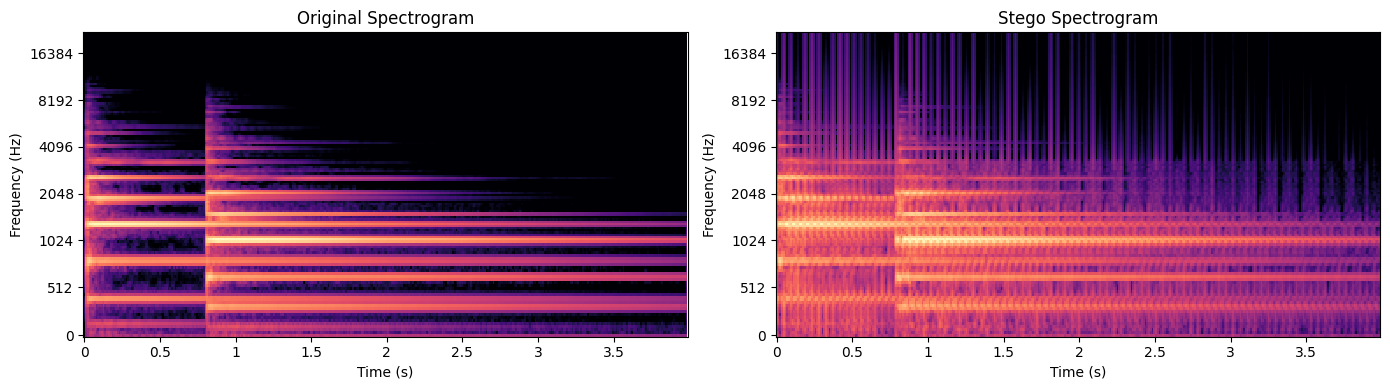

Original Audio:


Stego Audio:


Recovered payload:
Test message :)
Max sample difference (audio distortion): 1.322179

==================== Classical Phase Coding (Improved) vs Original ====================


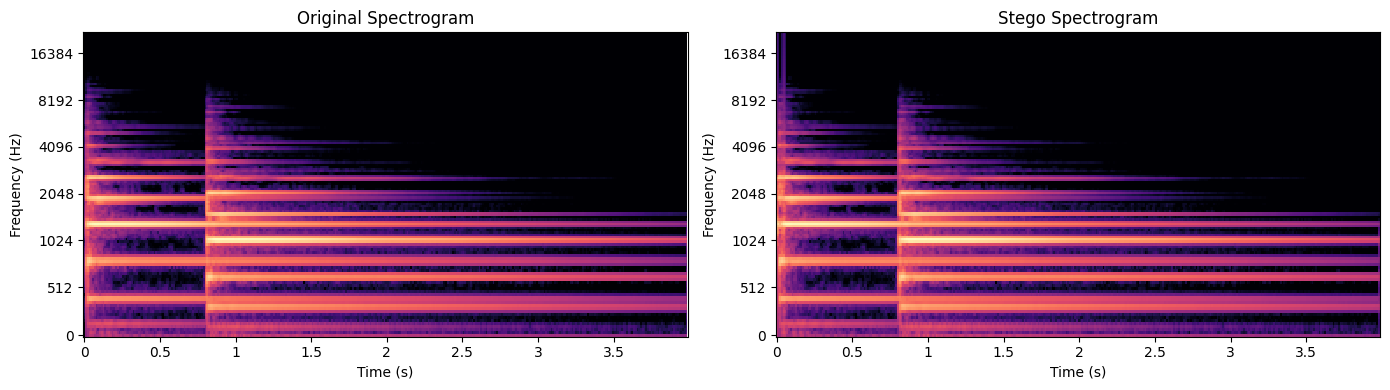

Original Audio:


Stego Audio:


Recovered payload:
Test message :)
Max sample difference (audio distortion): 0.765956


In [13]:
cover_name = "gong1.wav" # @param {type:"string"}

# --- TEXT PARAMS ---
payload_text = "Test message :)" # @param {type:"string"}
payload_bytes = payload_text.encode("utf-8")
block_size = 2048 # @param {type:"slider", min:512, max:8192, step:512}

# LOAD AUDIO
audio_data, sample_rate = sf.read(AUDIO_DIR / cover_name)
print(f"Loaded {cover_name}: {audio_data.shape}, {sample_rate} Hz")

if audio_data.ndim > 1:
    audio_data = audio_data[:, 0]

# 2.1
# --- ENCODING ---
stego_audio = phase_coding_encode(audio_data, payload_bytes, block_size=block_size)

# Compare original vs stego
display_audio_comparison(audio_data, stego_audio, sample_rate, title=f"Classical Phase Coding vs Original")

# --- DECODING ---
recovered_bytes = phase_coding_decode(stego_audio, block_size=block_size)
recovered_text = recovered_bytes.decode("utf-8")
print("Recovered payload:")
print(recovered_text)

# --- TEST ---
diff = np.max(np.abs(audio_data[:len(stego_audio)] - stego_audio))
print(f"Max sample difference (audio distortion): {diff:.6f}")

# 2.2
# --- ENCODING ---
stego_audio = phase_coding_encode2(audio_data, payload_bytes, sample_rate, block_size=block_size)

# Compare original vs stego
display_audio_comparison(audio_data, stego_audio, sample_rate, title=f"Classical Phase Coding (Improved) vs Original")

# --- DECODING ---
recovered_bytes = phase_coding_decode2(stego_audio, sample_rate, block_size=block_size)
recovered_text = recovered_bytes.decode("utf-8")
print("Recovered payload:")
print(recovered_text)

# --- TEST ---
diff = np.max(np.abs(audio_data[:len(stego_audio)] - stego_audio))
print(f"Max sample difference (audio distortion): {diff:.6f}")